---
### 03-2. 은닉층이 있는 신경망 만들기
---

In [33]:
# 이전 실습 코드 복사
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

# sklearn, pytorch library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


In [34]:
# 이전 실습 함수 복사

# 데이터로더
def make_DataSet(X_train, X_valid, y_train, y_valid, batch_size=32):
  # data -> tensor
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
  y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1,1)
  # Tensor dataset
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  # Dataloader
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, X_valid_tensor, y_valid_tensor

# train 함수
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)  # 데이터로더에 담긴 데이터셋의 길이
  num_batches = len(dataloader)   # 데이터셋 크기로 부터 배치개수 계산
  tr_loss = 0                     # 오차 저장 (초기값 0)
  model.train()

  for X, y in dataloader:              # 배치로부터 X, y 추출
    X, y = X.to(device), y.to(device)  # 추출한 데이터를 디바이스에 할당
    pred = model(X)                    # 모델의 예측결과
    loss = loss_fn(pred, y)            # 손실
    tr_loss += loss                    # epoch별 손실 기록
    loss.backward()                    # 역전파 (각 파라미터의 오차계산)
    optimizer.step()                   # 가중치 업데이트
    optimizer.zero_grad()              # 재계산을 위한 가중치 초기화

  tr_loss /= num_batches               # 최종 손실값 계산
  return tr_loss.item()                # 최종 손실값을 스칼라로 반환

# 검증 함수
def evaluate(X_valid_tensor, y_valid_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():        # 평가단계에서는 기울기를 계산하지 않음
    X, y = X_valid_tensor.to(device), y_valid_tensor.to(device)
    pred = model(X)
    val_loss = loss_fn(pred, y).item()
  return val_loss, pred

# 시각화 함수
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label = 'Train Error', marker='.')
  plt.plot(epochs, val_loss_list, label = 'Validation Error', marker='.')

  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid()
  plt.show()

#### 데이터 전처리

In [35]:
# data loading
df = pd.read_csv('data/boston_housing_price.csv')

# target 분리 (전체 데이터 사용)
y = df['medv']
X = df.drop('medv', axis=1)

# 검증데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

# data loader 준비
train_loader, X_valid_ts, y_valid_ts = make_DataSet(X_train, X_valid, y_train, y_valid, 32)

#### 모델 정의

In [36]:
n_feature = X.shape[1]
model2 = nn.Sequential(
    nn.Linear(n_feature,2),       # 모든변수(12개)의 입력을 받아, 2개의 출력 생성
    nn.ReLU(),                    # 활성화 함수
    nn.Linear(2,1),
    ).to(device)

loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr=0.01)

#### 학습 실행

In [37]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
  tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_valid_ts, y_valid_ts, model2, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)

  if (t + 1) % 10 == 0:           # epoch 10회당 출력
        print(f"Epoch {t+1:3d} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch  10 | Train Loss: 148.8754 | Val Loss: 123.9264
Epoch  20 | Train Loss: 81.5459 | Val Loss: 65.5064
Epoch  30 | Train Loss: 57.7224 | Val Loss: 46.3545
Epoch  40 | Train Loss: 49.1119 | Val Loss: 40.8282
Epoch  50 | Train Loss: 41.7326 | Val Loss: 36.1640
Epoch  60 | Train Loss: 36.7795 | Val Loss: 32.1890
Epoch  70 | Train Loss: 31.2412 | Val Loss: 28.7964
Epoch  80 | Train Loss: 27.4492 | Val Loss: 26.0246
Epoch  90 | Train Loss: 24.4552 | Val Loss: 23.4293
Epoch 100 | Train Loss: 22.9989 | Val Loss: 21.9847


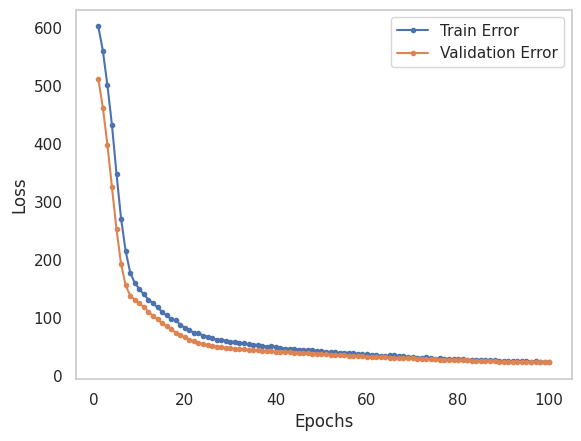

In [38]:
learning_curve(tr_loss_list, val_loss_list)

In [39]:
# 모델 평가지표
_, pred = evaluate(X_valid_ts, y_valid_ts, model2, loss_fn, device)

mae = mean_absolute_error(y_valid_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_valid_ts.cpu().numpy(), pred.cpu().numpy())

print('MAE:', mae)
print('MAPE:', mape)

MAE: 2.952864408493042
MAPE: 0.14836987853050232
